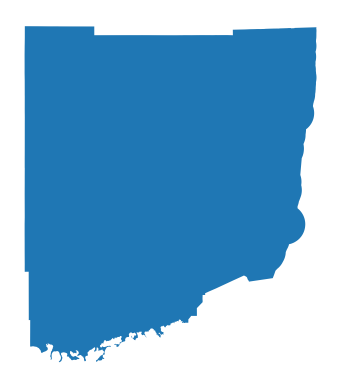

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Load the giant map of all US Counties
counties = gpd.read_file("tl_2023_us_county.shp")

# 2. Filter the map to ONLY show Miami-Dade County in Florida 
miami = counties[(counties['NAME'] == 'Miami-Dade') & (counties['STATEFP'] == '12')]

# 3. Draw a quick plot of the county to make sure it worked
miami.plot()
plt.axis('off')
plt.savefig('CleanMap_1.png', bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()

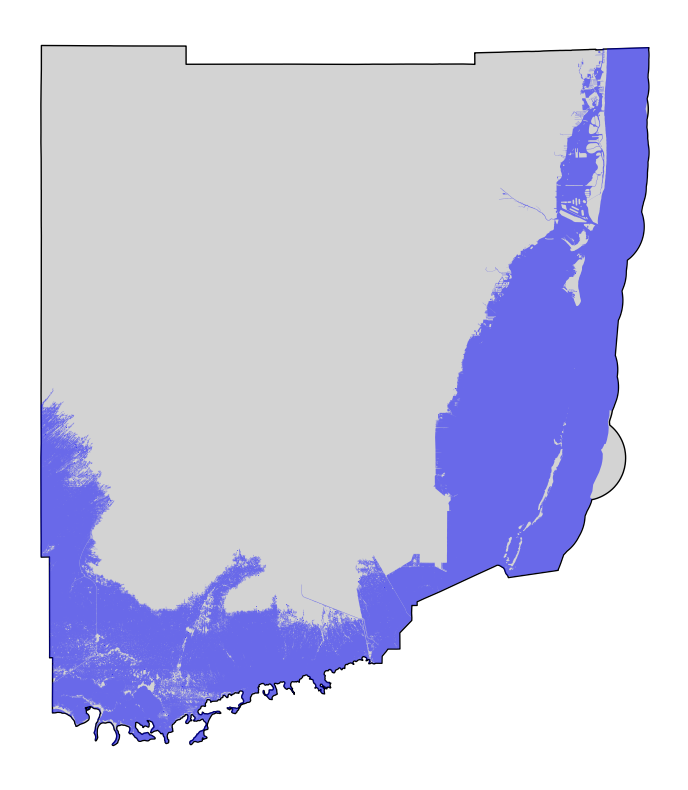

In [2]:
# 1. Load the specific 1-foot sea level rise layer from the GeoPackage
slr_data = gpd.read_file("FL_SE_slr_final_dist.gpkg", layer="FL_SE_slr_1_0ft")

# 2. Make sure the map coordinates match perfectly so they actually line up
if slr_data.crs != miami.crs:
    slr_data = slr_data.to_crs(miami.crs)

# 3. Use CLIP instead of overlay
miami_flood = gpd.clip(slr_data, miami)

# 4. Plot them together
fig, ax = plt.subplots(figsize=(10, 10))
miami.plot(ax=ax, color='lightgrey', edgecolor='black')
miami_flood.plot(ax=ax, color='blue', alpha=0.5) 
plt.axis('off')
plt.savefig('CleanMap_2.png', bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()

In [3]:
%pip install rasterio

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


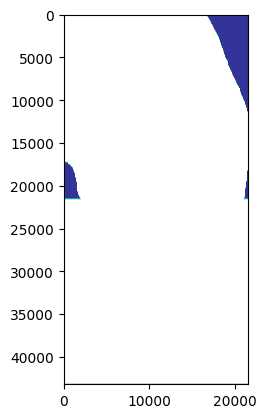

<AxesSubplot: >

In [4]:
import rasterio
from rasterio.merge import merge
from rasterio.plot import show
import glob

# 1. Find all 8 of your .tif files in your Capstone Project folder
tif_files = glob.glob("*.tif")

# 2. Open all of them so Python can read the data
src_files_to_mosaic = []
for fp in tif_files:
    src = rasterio.open(fp)
    src_files_to_mosaic.append(src)

# 3. Stitch them together into one giant map
mosaic, out_trans = merge(src_files_to_mosaic)

# 4. Save this new stitched map to your folder so you only ever have to do this once
out_meta = src.meta.copy()
out_meta.update({
    "driver": "GTiff",
    "height": mosaic.shape[1],
    "width": mosaic.shape[2],
    "transform": out_trans
})

with rasterio.open("miami_merged_elevation.tif", "w", **out_meta) as dest:
    dest.write(mosaic)

# 5. Plot the final stitched map on the screen to verify it worked
show(mosaic, cmap='terrain')

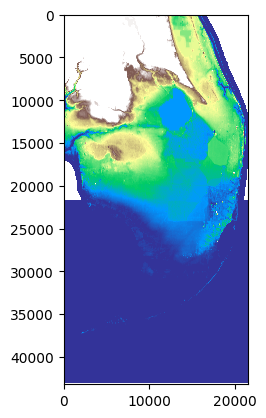

<AxesSubplot: >

In [5]:
import numpy as np
from rasterio.plot import show

# 1. Hide the fake -9999 "No Data" numbers by turning them into NaNs 
plot_data = np.where(mosaic < -100, np.nan, mosaic)

# 2. Plot it again, telling Python to only look at realistic elevations (0 to 15 meters)
show(plot_data, cmap='terrain', vmin=0, vmax=15)

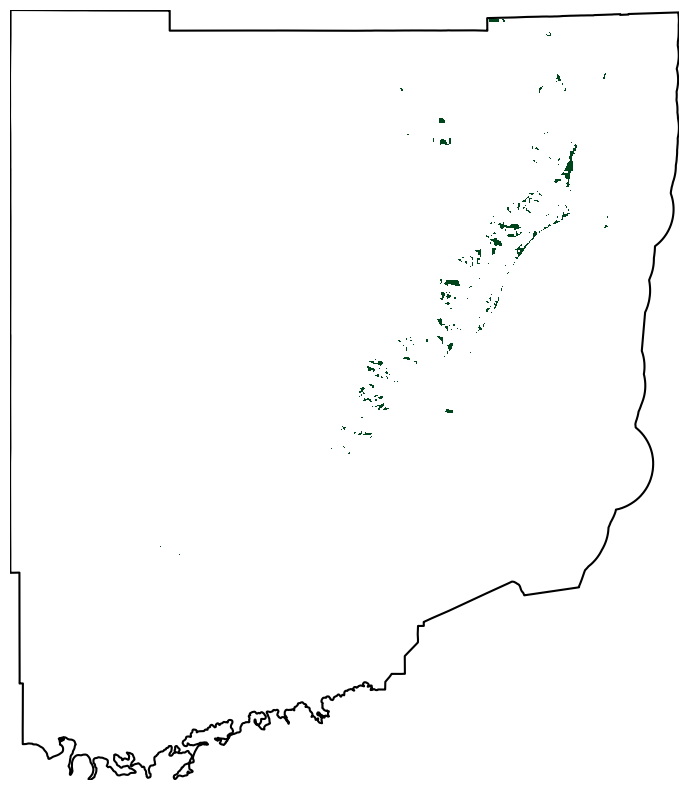

In [6]:
import rasterio
from rasterio.mask import mask
from rasterio.plot import show
import numpy as np
import matplotlib.pyplot as plt

# 1. Open your newly stitched map
with rasterio.open("miami_merged_elevation.tif") as src:
    # 2. Use the 'miami' county shape to clip the raster
    out_image, out_transform = mask(src, miami.geometry, crop=True)

# 3. Filter the elevation (NaN makes the water invisible)
safe_elevation = np.where(out_image[0] > 3.0, 1.0, np.nan)

# 4. Plot the results together
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the green safe zones, locking them to real GPS coordinates
show(safe_elevation, transform=out_transform, ax=ax, cmap='Greens', vmin=0, vmax=1)

# Draw the county boundary exactly over the top
miami.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.5)

# Strip axes and save it clean
plt.axis('off')
plt.savefig('CleanMap_3.png', bbox_inches='tight', pad_inches=0, dpi=300, transparent=True)
plt.show()

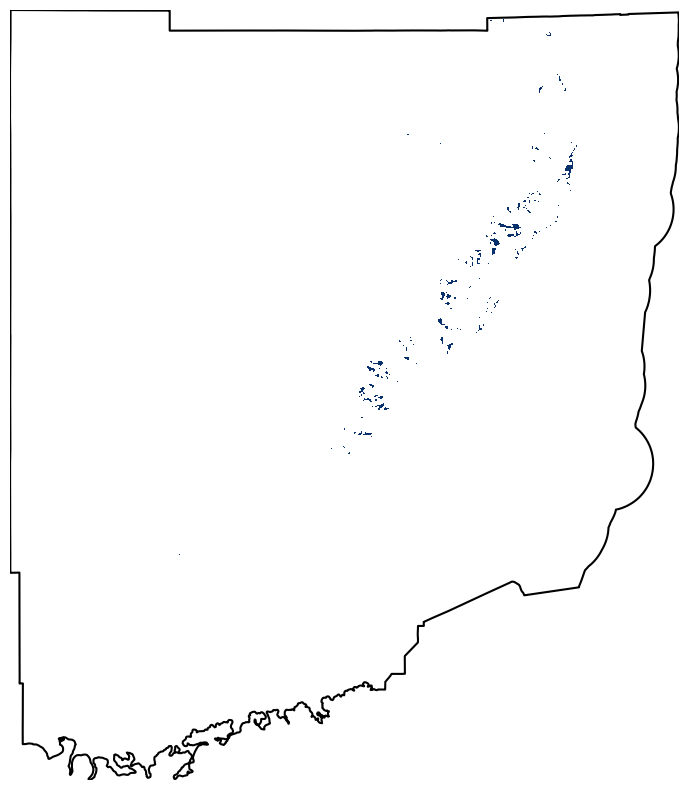

In [7]:
from rasterio.plot import show

# 1. Calculate the slope
dy, dx = np.gradient(out_image[0])
slope = np.sqrt(dx**2 + dy**2)

# 2. Filter for BOTH High (> 3.0m) AND Flat (< 0.5 slope), making everything else invisible (NaN)
safe_and_flat = np.where((out_image[0] > 3.0) & (slope < 0.5), 1.0, np.nan)

# 3. Plot it
fig, ax = plt.subplots(figsize=(10, 10))

# Draw the safe/flat zones in blue
show(safe_and_flat, transform=out_transform, ax=ax, cmap='Blues', vmin=0, vmax=1)

# Draw the crisp county outline over the top
miami.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.5)

# Save the clean image
plt.axis('off')
plt.savefig('CleanMap_4.png', bbox_inches='tight', pad_inches=0, dpi=300, transparent=True)
plt.show()

Pulling population data from the Census API...


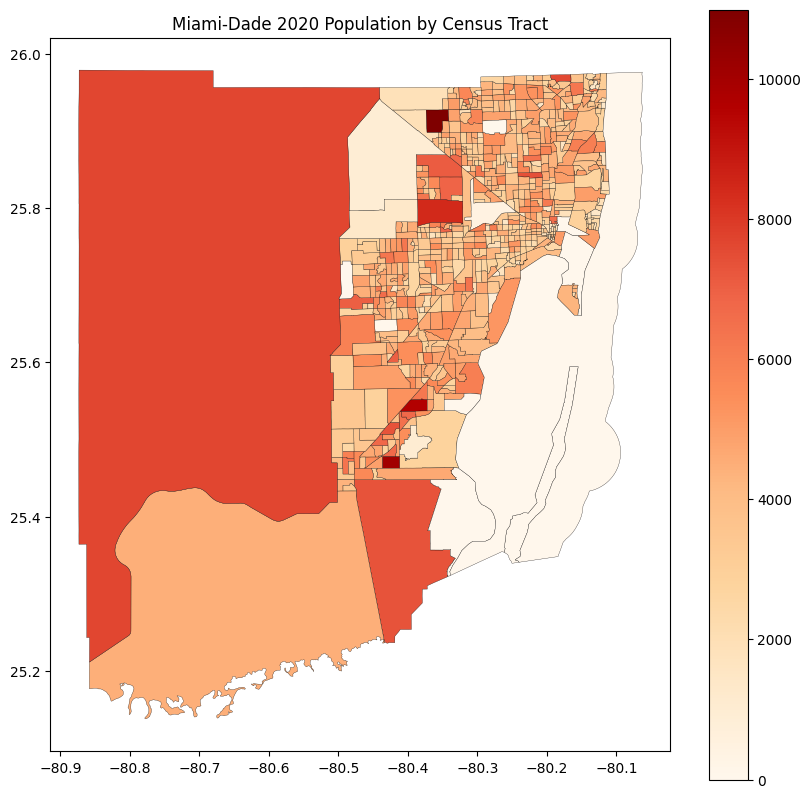

In [8]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Download the Census Tracts for Florida directly from the government
print("Downloading Census Tract boundaries...")
tracts = gpd.read_file("https://www2.census.gov/geo/tiger/TIGER2020/TRACT/tl_2020_12_tract.zip")

# Filter for just Miami-Dade County 
miami_tracts = tracts[tracts['COUNTYFP'] == '086']

# 2. Rip the 2020 Total Population numbers straight from the US Census API
print("Pulling population data from the Census API...")
url = "https://api.census.gov/data/2020/dec/pl?get=P1_001N&for=tract:*&in=state:12&in=county:086"
pop_data = pd.read_json(url)

# Clean up the API data table so it's readable
pop_data.columns = pop_data.iloc[0]
pop_data = pop_data[1:]
pop_data = pop_data.rename(columns={'P1_001N': 'Population'})
pop_data['Population'] = pop_data['Population'].astype(int)

# 3. Glue the population numbers to the map boundaries
miami_pop_map = miami_tracts.merge(pop_data, left_on='TRACTCE', right_on='tract')

# 4. Plot a population heatmap to prove it worked
fig, ax = plt.subplots(figsize=(10, 10))
miami_pop_map.plot(column='Population', cmap='OrRd', legend=True, ax=ax, edgecolor='black', linewidth=0.2)
plt.title("Miami-Dade 2020 Population by Census Tract")
plt.show()

 FINAL ANALYSIS RESULT 
A 1-foot sea level rise in Miami-Dade County will permanently displace approximately 135,090 people.


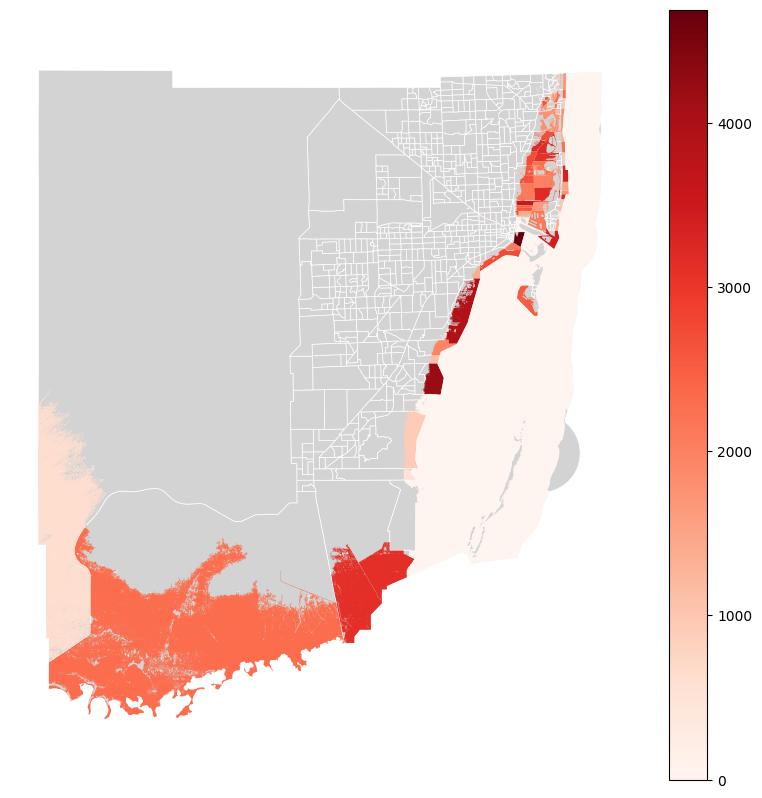

In [9]:
import warnings
warnings.filterwarnings('ignore') # Hides math warnings

# 1. Project both maps to Web Mercator 
miami_pop_map = miami_pop_map.to_crs(epsg=3857)
miami_flood = miami_flood.to_crs(epsg=3857)

# 2. Calculate the original total area of every tract
miami_pop_map['orig_area'] = miami_pop_map.geometry.area

# 3. Intersect the flood map into the population map
flooded_tracts = gpd.overlay(miami_pop_map, miami_flood, how='intersection')

# 4. Calculate the area of the water that is specifically inside each tract
flooded_tracts['flood_area'] = flooded_tracts.geometry.area

# 5. Math time: Calculate the percentage flooded, then multiply by the population
flooded_tracts['pct_flooded'] = flooded_tracts['flood_area'] / flooded_tracts['orig_area']
flooded_tracts['displaced_people'] = flooded_tracts['Population'] * flooded_tracts['pct_flooded']

# 6. Add it all up to get final metric
total_displaced = int(flooded_tracts['displaced_people'].sum())

print(f" FINAL ANALYSIS RESULT ")
print(f"A 1-foot sea level rise in Miami-Dade County will permanently displace approximately {total_displaced:,} people.")

# 7. Plot the impact map
fig, ax = plt.subplots(figsize=(10,10))

# Draw the base map
miami_pop_map.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.5)

# Draw the red displacement heat map over it
flooded_tracts.plot(column='displaced_people', cmap='Reds', legend=True, ax=ax)

# Strip the axes and save it clean
plt.axis('off')
plt.savefig('Clean_Final_Displacement.png', bbox_inches='tight', pad_inches=0, dpi=300, transparent=True)
plt.show()

In [10]:
# 1. Count how many pixels survived the High AND Flat Map Algebra test
safe_pixels = np.count_nonzero(safe_and_flat == 1.0)

# 2. Convert pixels to area
# USGS 1/3 arc-second DEM pixels are roughly 10 meters by 10 meters (100 sq meters)
sq_meters = safe_pixels * 100
sq_miles = sq_meters / 2589988.11 # Math conversion from sq meters to sq miles

# 3. Calculate the population density
displaced_pop = 135090
density = displaced_pop / sq_miles

print(f" THE FINAL METRIC ")
print(f"Total Available Safe & Flat Land: {sq_miles:.2f} square miles")
print(f"Relocation Population Density: {density:.0f} people per square mile")

 THE FINAL METRIC 
Total Available Safe & Flat Land: 69.43 square miles
Relocation Population Density: 1946 people per square mile


In [11]:
!pip install contextily

Defaulting to user installation because normal site-packages is not writeable
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [contextily]4 [geopy]


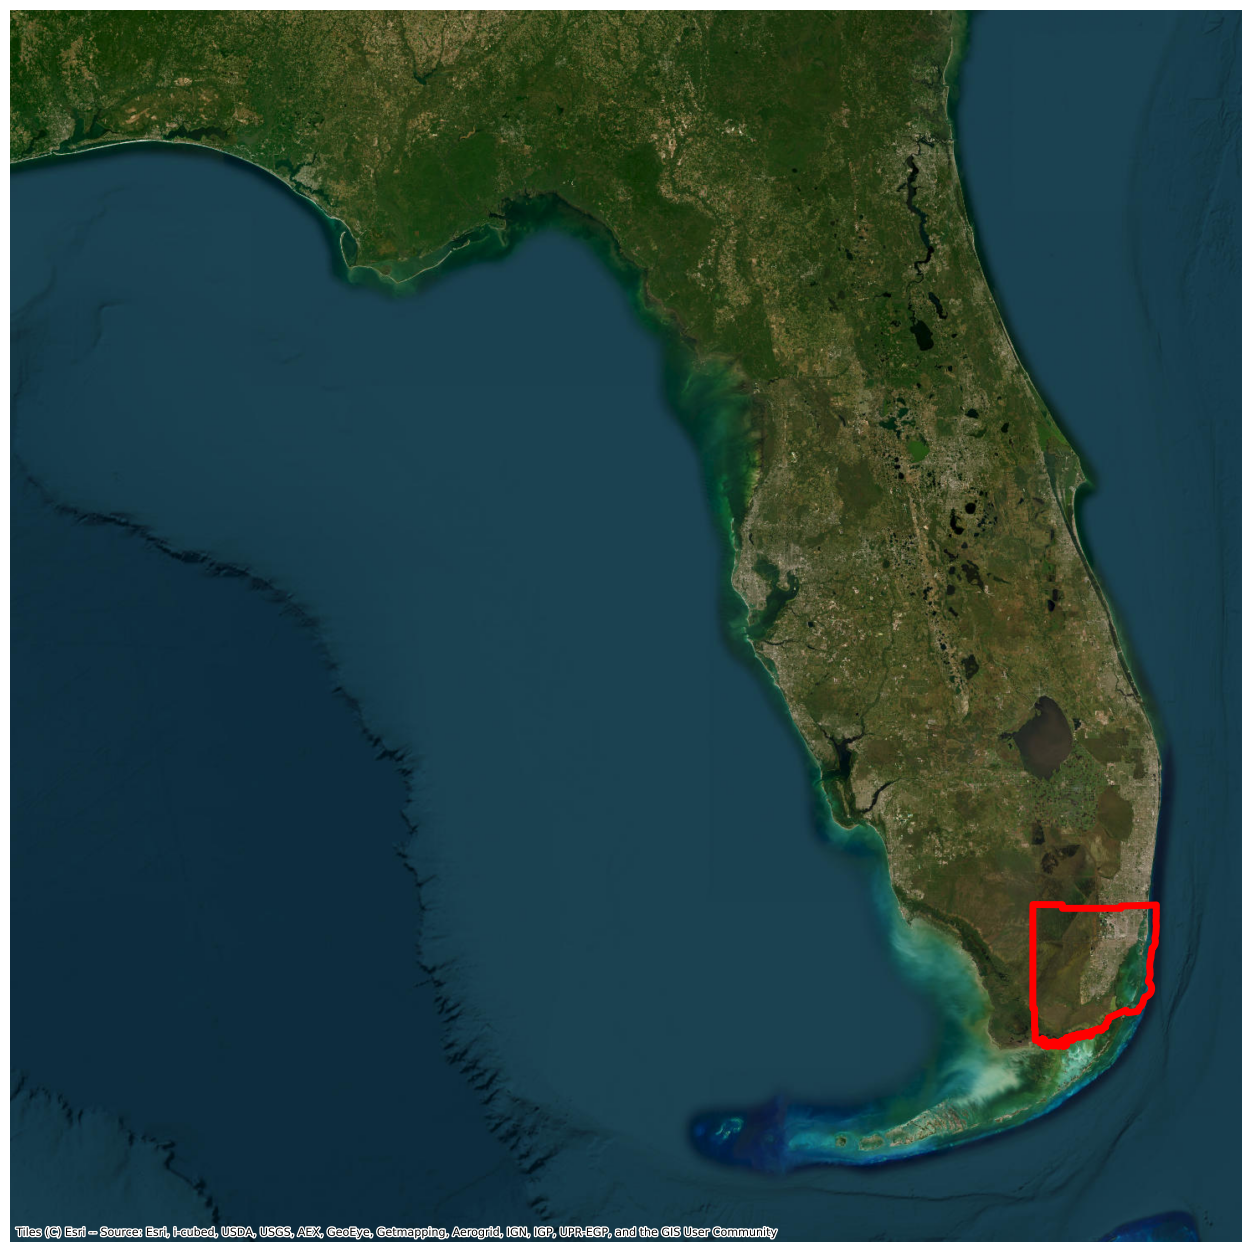

In [13]:
import matplotlib.pyplot as plt
import contextily as cx

# 1. Project Miami shapefile to Web Mercator
miami_web = miami.to_crs(epsg=3857)

# 2. Make the canvas massive for high resolution
fig, ax = plt.subplots(figsize=(16, 16))

# 3. Plot Miami-Dade with outline 
miami_web.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=5)

# 4. Set the exact camera bounds to show the state of Florida 
ax.set_xlim(-9.75e6, -8.85e6) 
ax.set_ylim(2.75e6, 3.65e6)

# 5. Pull the satellite map
cx.add_basemap(ax, source=cx.providers.Esri.WorldImagery, zoom=8)

# 6. Strip the axes and save it
plt.axis('off')
plt.savefig('Final_Hero_Image_Florida.png', bbox_inches='tight', pad_inches=0, dpi=600)
plt.show()
